# Análisis de repositorios populares de GitHub
En este proyecto se busca explorar las tendencias del ecosistema tecnologico a partir de los datos del repositorio público de GitHub. 

## 1. Importar librerías y cargar el dataset
En esta sección se importan las librerías necesarias y se carga el dataset generado por el script obtener_datos_github.py.

In [7]:
# Importar librerías necesarias para el análisis
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
%matplotlib inline

# Cargar el dataset de repositorios populares
ruta_csv = '../datos/repositorios_populares.csv'
try:
    df = pd.read_csv(ruta_csv)
except Exception as e:
    print(f'Error al cargar el archivo CSV: {e}')

# Mostrar las primeras filas para revisar la estructura
df.head()

,nombre,lenguaje,estrellas,forks,watchers,fecha_creacion,fecha_actualizacion
0,build-your-own-x,Markdown,472895,44330,472895,2018-05-09T12:03:18Z,2026-03-06T22:36:35Z
1,awesome,Desconocido,443117,33401,443117,2014-07-11T13:42:37Z,2026-03-06T22:39:39Z
2,freeCodeCamp,TypeScript,437843,43524,437843,2014-12-24T17:49:19Z,2026-03-06T22:44:45Z
3,public-apis,Python,404789,43689,404789,2016-03-20T23:49:42Z,2026-03-06T22:43:48Z
4,free-programming-books,Python,383680,66012,383680,2013-10-11T06:50:37Z,2026-03-06T21:31:05Z


## 2. Análisis de lenguajes más utilizados
En esta sección se identifican los lenguajes principales más frecuentes en los repositorios. Se visualizan los resultados con gráficos de barras.

/tmp/ipykernel_18372/420604587.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lenguajes_frecuentes.values, y=lenguajes_frecuentes.index, palette='viridis')


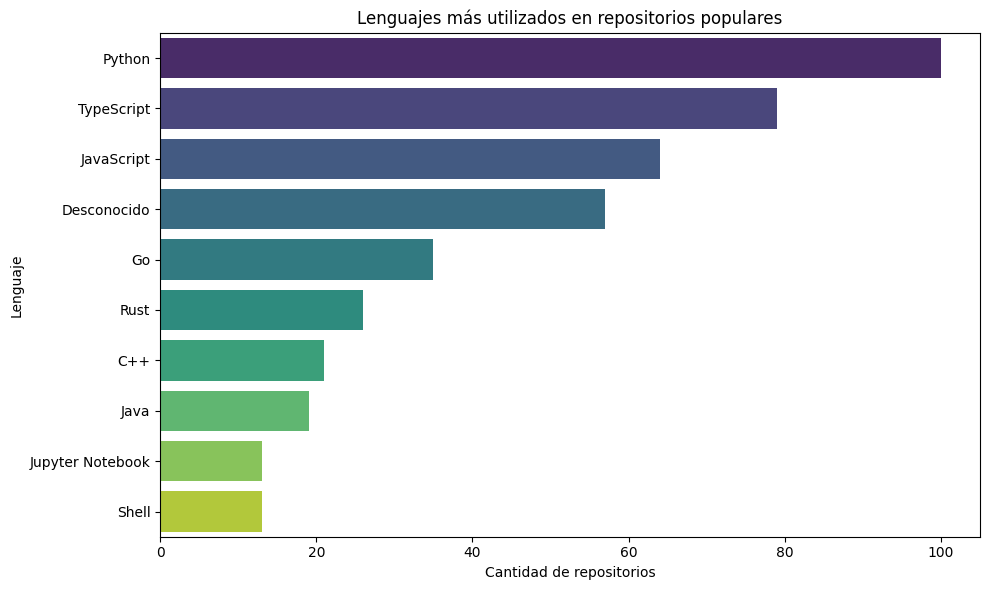

In [9]:
# Contar los lenguajes más frecuentes
if 'df' in globals():
    lenguajes_frecuentes = df['lenguaje'].value_counts().head(10)
    # Visualizar con gráfico de barras 
    plt.figure(figsize=(10,6))
    sns.barplot(x=lenguajes_frecuentes.values, y=lenguajes_frecuentes.index, palette='viridis')
    plt.title('Lenguajes más utilizados en repositorios populares')
    plt.xlabel('Cantidad de repositorios')
    plt.ylabel('Lenguaje')
    plt.tight_layout()
    plt.show()
else:
    print('El DataFrame df no está definido. Ejecuta la celda de carga de datos primero.')

## 3. Distribución de estrellas por lenguaje
En esta sección se visualiza la distribución del número de estrellas por cada lenguaje principal. Comparando por la popularidad entre lenguajes.

/tmp/ipykernel_17049/681203645.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='lenguaje', y='estrellas', data=df_top, palette='Set2')


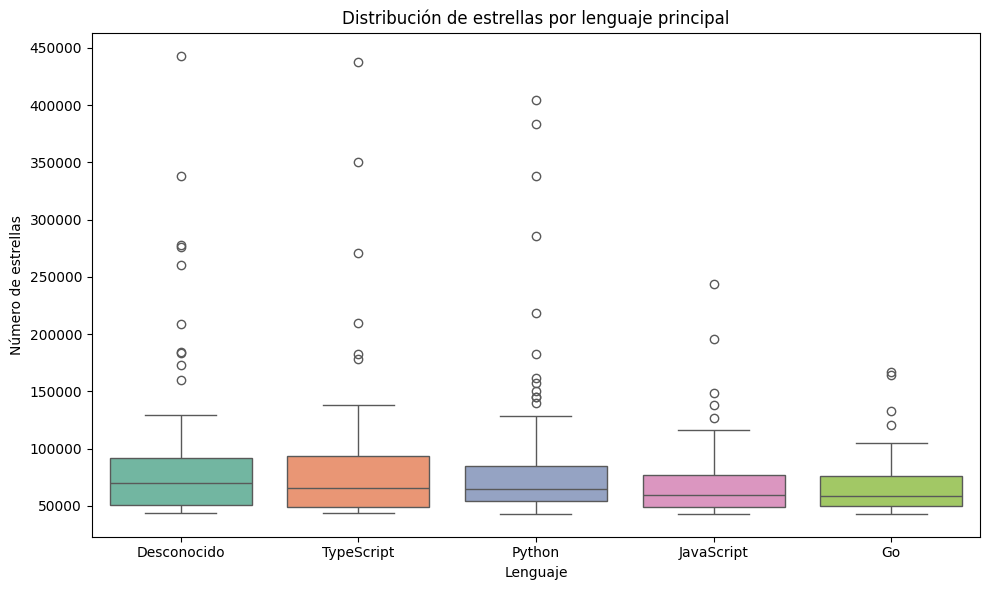

In [8]:
# Seleccionar los lenguajes principales más frecuentes
if 'df' in globals():
    top_lenguajes = df['lenguaje'].value_counts().head(5).index.tolist()
    df_top = df[df['lenguaje'].isin(top_lenguajes)]
    # Visualizar distribución de estrellas por lenguaje (boxplot)
    plt.figure(figsize=(10,6))
    sns.boxplot(x='lenguaje', y='estrellas', data=df_top, palette='Set2')
    plt.title('Distribución de estrellas por lenguaje principal')
    plt.xlabel('Lenguaje')
    plt.ylabel('Número de estrellas')
    plt.tight_layout()
    plt.show()
else:
    print('El DataFrame df no está definido. Ejecuta la celda de carga de datos primero.')

## 4. Crecimiento de repositorios en el tiempo
En esta sección se analiza cómo ha crecido el número de repositorios populares a traves del tiempo. Se crea una visualización temporal para observar tendencias.

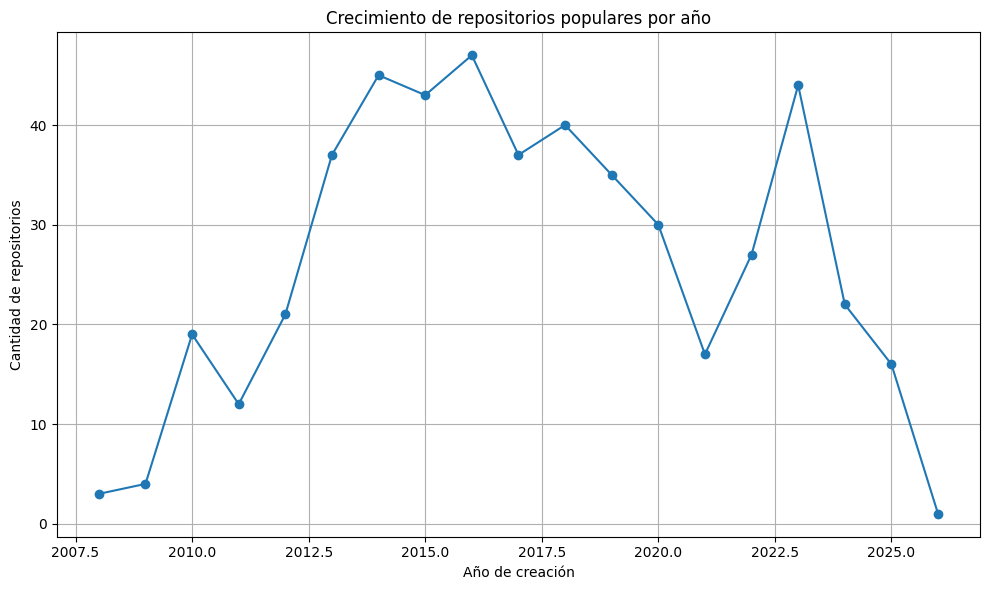

In [9]:
# Convertir la columna de fecha de creación a tipo datetime
df['fecha_creacion'] = pd.to_datetime(df['fecha_creacion'])
 
# Agrupar por año de creación
df['anio_creacion'] = df['fecha_creacion'].dt.year
repos_por_anio = df.groupby('anio_creacion').size()
 
# Visualizar el crecimiento de repositorios a lo largo del tiempo
plt.figure(figsize=(10,6))
plt.plot(repos_por_anio.index, repos_por_anio.values, marker='o')
plt.title('Crecimiento de repositorios populares por año')
plt.xlabel('Año de creación')
plt.ylabel('Cantidad de repositorios')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Identificación de repositorios más influyentes
En esta sección se identifican los repositorios con más estrellas, Forks y visitantes. Se visualizan los resultados y se comentan las conclusiones.

In [13]:
# Repositorios con más estrellas
repos_top_estrellas = df.sort_values('estrellas', ascending=False).head(5)
print("Repositorios con más estrellas:")
print(repos_top_estrellas[['nombre', 'estrellas', 'lenguaje']])
 
# Repositorios con más forks
repos_top_forks = df.sort_values('forks', ascending=False).head(5)
print("\nRepositorios con más forks:")
print(repos_top_forks[['nombre', 'forks', 'lenguaje']])
 
# Repositorios con más visitantes
repos_top_visitantes = df.sort_values('watchers', ascending=False).head(5)
print("\nRepositorios con más visitantes:")
print(repos_top_visitantes[['nombre', 'watchers', 'lenguaje']])

Repositorios con más estrellas:
                   nombre  estrellas     lenguaje
0        build-your-own-x     472895     Markdown
1                 awesome     443117  Desconocido
2            freeCodeCamp     437844   TypeScript
3             public-apis     404787       Python
4  free-programming-books     383680       Python

Repositorios con más forks:
                          nombre  forks     lenguaje
345          first-contributions  99112  Desconocido
30                     gitignore  82788  Desconocido
6    coding-interview-university  81644  Desconocido
29                     bootstrap  79062          MDX
20                    tensorflow  75221          C++

Repositorios con más visitantes:
                   nombre  watchers     lenguaje
0        build-your-own-x    472895     Markdown
1                 awesome    443117  Desconocido
2            freeCodeCamp    437844   TypeScript
3             public-apis    404787       Python
4  free-programming-books    383680       

## 7. Otras vistas del análisis
En esta sección se agregan visualizaciones que destacan tendencias y patrones del Dataset

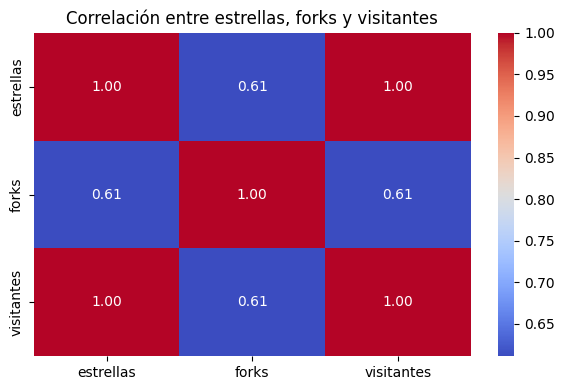

In [10]:

if 'df' in globals():
    # Renombrar la columna watchers a visitantes 
    if 'visitantes' not in df.columns and 'watchers' in df.columns:
        df = df.rename(columns={'watchers': 'visitantes'})

    # Relación entre estrellas, forks y visitantes
    fig = px.scatter(df, x='estrellas', y='forks', size='visitantes', color='lenguaje',
                    hover_data=['nombre'],
                    title='Relación entre estrellas, forks y visitantes por lenguaje',
                    labels={'estrellas':'Estrellas','forks':'Forks','visitantes':'Visitantes','lenguaje':'Lenguaje'})
    fig.update_layout(template='plotly_dark')
    fig.show()

    # Correlación entre variables numéricas
    corr = df[['estrellas','forks','visitantes']].corr()
    plt.figure(figsize=(6,4))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlación entre estrellas, forks y visitantes')
    plt.tight_layout()
    plt.show()

    # Proporción de lenguajes principales
    lenguajes_pie = df['lenguaje'].value_counts().head(7)
    fig2 = px.pie(values=lenguajes_pie.values, names=lenguajes_pie.index,
                  title='Proporción de lenguajes principales en repositorios populares',
                  color_discrete_sequence=px.colors.sequential.Rainbow)
    fig2.show()
else:
    print('El DataFrame df no está definido. Ejecuta la celda de carga de datos primero.')

## 8. Conclusiones del análisis
- Los lenguajes más utilizados en los repositorios populares de GitHub, como JavaScript, Python y TypeScript, reflejan las preferencias actuales del mercado y la comunidad tecnológica.
- La concentración de estrellas en ciertos lenguajes indica proyectos altamente influyentes, lo que puede orientar decisiones sobre tecnologías a adoptar en nuevos desarrollos.
- El crecimiento sostenido de repositorios a lo largo de los años evidencia la evolución y rápida adopción de nuevas tendencias tecnológicas, marcando oportunidades para innovación.
- Los proyectos más influyentes suelen ser iniciativas de código abierto.
- El análisis visual de los datos permite identificar patrones clave entre popularidad, lenguaje y actividad, facilitando la toma de decisiones estratégicas para equipos de desarrollo y áreas de negocio.